In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

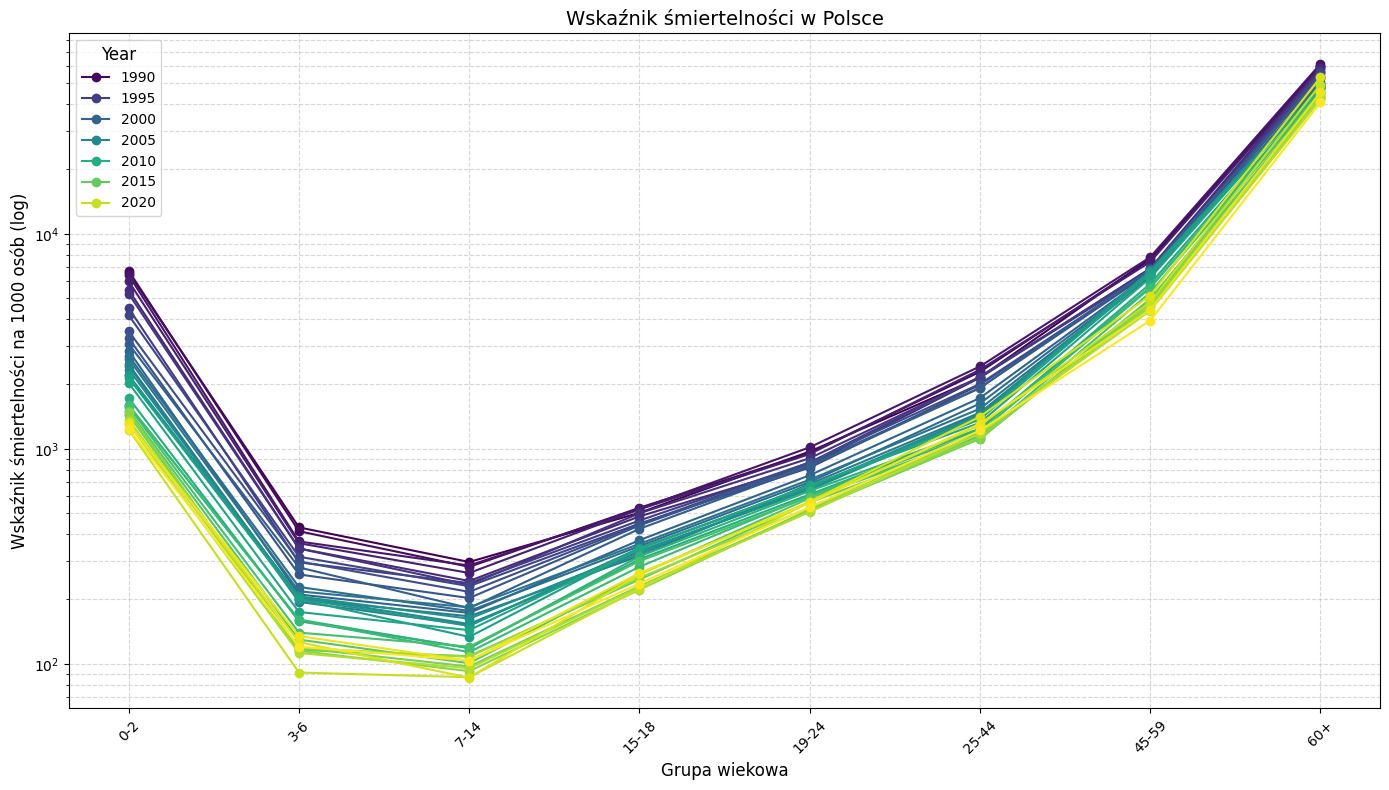

In [2]:
df = pd.read_csv('POLdeath.txt')

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

years_to_compare = [1989,1995,2005,2015,2021,2023]
years_to_compare = list(range(1989, 2024))

df_years = df[df['Year'].isin(years_to_compare)].copy()

age_bins = [0, 2, 6, 14, 18, 24, 44, 59, 120]
age_labels = ['0-2', '3-6', '7-14', '15-18', '19-24', '25-44', '45-59', '60+']

df_years['Age_Group'] = pd.cut(df_years['Age'], bins=age_bins, labels=age_labels, right=False)

grouped_data = df_years.groupby(['Year', 'Age_Group'], observed=True)['Deaths'].sum().reset_index()

plt.figure(figsize=(14, 8))

colors = plt.cm.viridis(np.linspace(0, 1, len(years_to_compare)))
populacja = pd.read_csv('population_pl.csv', delimiter=';')
for year in populacja.columns[1:]: 
    populacja[year] = populacja[year].astype(str).str.replace(',', '.').astype(float)
mortality_rates = []
for _, row in grouped_data.iterrows():
    year = row['Year']
    age_group = row['Age_Group']
    
    pop = populacja.loc[populacja['Grupy wieku'] == age_group, str(year)].values[0]
    
    rate = (row['Deaths'] / pop) * 1000
    mortality_rates.append(rate)

grouped_data['Mortality_Rate'] = mortality_rates

for year, color in zip(years_to_compare, colors):
    year_data = grouped_data[grouped_data['Year'] == year]
    plt.semilogy(year_data['Age_Group'],
                 year_data['Mortality_Rate'],
                 'o-',
                 color=color,
                 label=str(year) if year % 5 == 0 else None)

plt.xlabel('Grupa wiekowa', fontsize=12)
plt.ylabel('Wskaźnik śmiertelności na 1000 osób (log)', fontsize=12)
plt.title('Wskaźnik śmiertelności w Polsce', fontsize=14)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xticks(rotation=45)
plt.legend(title='Year', fontsize=10, title_fontsize=12)
plt.tight_layout()

plt.show()

In [3]:
mortality_matrix = grouped_data.pivot(
    index='Age_Group', columns='Year', values='Mortality_Rate'
)

In [4]:
mortality_matrix 

Year,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Age_Group,,,,,,,,,,,,,,,,,,,,,
0-2,6600.920069,6710.179641,6409.453653,6005.060089,5471.587198,5251.533742,4499.279539,4179.003021,3514.694202,3261.437908,...,1505.022669,1437.483049,1436.469015,1484.347826,1358.109265,1304.572908,1225.004504,1330.231675,1300.589791,1236.476043
3-6,430.555556,413.312693,370.460048,363.482671,343.639576,343.324251,296.105115,314.437984,298.850575,260.179799,...,129.436326,115.723733,118.448704,114.837531,118.590168,112.106136,90.966519,125.984252,134.415420,120.033923
7-14,297.270764,282.229274,286.143974,264.300203,242.554939,232.785521,237.035482,229.410513,215.906635,202.057793,...,100.580532,108.450517,97.030667,92.309651,107.590966,95.294264,86.501462,86.101238,103.209952,103.472846
15-18,503.558719,531.127558,524.338173,522.431866,484.349259,500.809717,463.531287,448.667712,445.216049,439.756746,...,260.153472,246.397324,229.330514,220.897141,250.985273,227.129338,223.013894,261.209666,264.044187,235.912558
19-24,970.154149,957.120000,1015.341265,944.495554,842.247596,903.330386,862.847222,816.633551,864.714086,844.529750,...,588.931336,562.689621,515.376380,521.816151,531.573457,508.129236,565.619705,566.663678,560.058954,535.137413
25-44,2144.220026,2278.583765,2414.809677,2330.310429,2139.910471,2147.035433,2162.174184,1983.505155,2002.981030,1921.311475,...,1119.696970,1109.562589,1113.310408,1131.184786,1179.977979,1177.315884,1287.493468,1410.356446,1307.866184,1215.981524
45-59,7670.708266,7568.505080,7779.044904,7392.507688,6901.979654,6751.995670,6842.862855,6635.885985,6673.577815,6608.717883,...,4971.900089,4948.864856,4780.978081,4644.659790,4549.802188,4383.224164,4796.762315,5155.438897,4416.487163,3944.588745
60+,60028.970404,60176.494676,61602.053140,59152.857425,58870.366777,57159.417513,56333.711048,56220.917226,54468.100754,53141.146589,...,43010.649656,44313.647406,42355.750048,43193.125962,43550.494157,42206.734143,49458.018606,53471.399932,45409.197104,40808.768296


In [5]:
from statsmodels.tsa.arima.model import ARIMA

# Log-transformacja
log_mu = np.log(mortality_matrix.values) 
years = mortality_matrix.columns.values
age_groups = mortality_matrix.index.values

alpha = log_mu.mean(axis=1)
A = log_mu - alpha[:, np.newaxis]

U, S, Vt = np.linalg.svd(A)

beta  = U[:, 0] / U[:, 0].sum()
kappa = S[0] * Vt[0, :] * U[:, 0].sum()

In [6]:
n_forecast = 10
future_years = np.arange(2024, 2024 + n_forecast)

arima = ARIMA(kappa, order=(0, 1, 0)).fit()

forecast_obj = arima.get_forecast(steps=n_forecast)
kappa_future = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05)

if not isinstance(conf_int, pd.DataFrame):
    conf_int = pd.DataFrame(conf_int, columns=['lower', 'upper'])

In [7]:
# Prognozowana log-śmiertelność: outer product beta i kappa_future + alpha
log_mu_forecast = np.outer(beta, kappa_future) + alpha[:, np.newaxis]
mu_forecast = np.exp(log_mu_forecast)  # shape: (8, 10)

In [8]:
print(conf_int.columns.tolist())

['lower', 'upper']


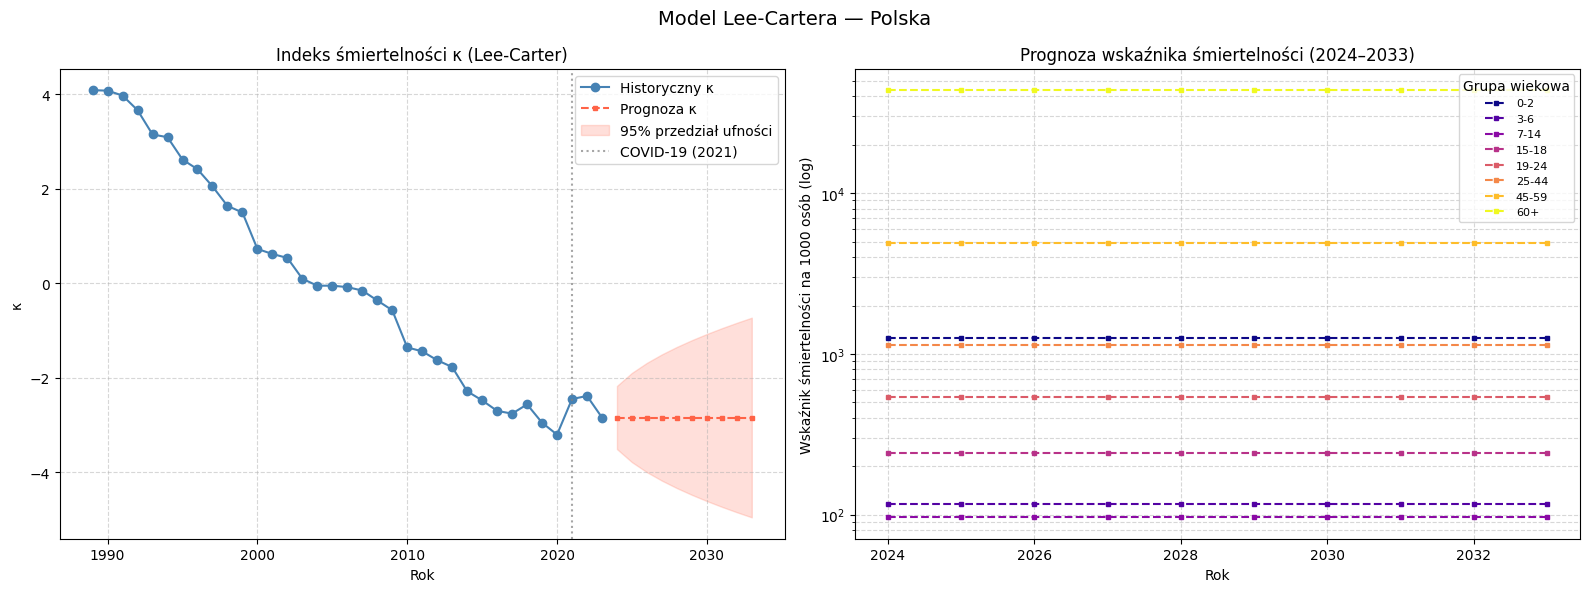

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lewy: historyczny i prognozowany kappa
axes[0].plot(years, kappa, 'o-', color='steelblue', label='Historyczny κ')
axes[0].plot(future_years, kappa_future, 's--',markersize = 3, color='tomato', label='Prognoza κ')
axes[0].fill_between(future_years,
                     conf_int['lower'],
                     conf_int['upper'],
                     color='tomato', alpha=0.2, label='95% przedział ufności')
axes[0].axvline(x=2021, color='gray', linestyle=':', alpha=0.7, label='COVID-19 (2021)')
axes[0].set_title('Indeks śmiertelności κ (Lee-Carter)')
axes[0].set_xlabel('Rok')
axes[0].set_ylabel('κ')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

colors_forecast = plt.cm.plasma(np.linspace(0, 1, len(age_groups)))
for i, (age, color) in enumerate(zip(age_groups, colors_forecast)):
    axes[1].semilogy(future_years, mu_forecast[i, :], 's--', color=color, label=age,markersize = 3)

axes[1].set_title('Prognoza wskaźnika śmiertelności (2024–2033)')
axes[1].set_xlabel('Rok')
axes[1].set_ylabel('Wskaźnik śmiertelności na 1000 osób (log)')
axes[1].legend(title='Grupa wiekowa', fontsize=8)
axes[1].grid(True, which='both', linestyle='--', alpha=0.5)

plt.suptitle('Model Lee-Cartera — Polska', fontsize=14)
plt.tight_layout()
plt.show()

## Wnioski

### Indeks śmiertelności κ (1989–2023)

Indeks κ spada monotonicznie z ~4 (1989) do ~−3.5 (2020), potwierdzając
systematyczną poprawę przeżywalności w Polsce w okresie potransformacyjnym.
W 2021 roku widoczny jest wyraźny skok κ w górę, będący bezpośrednim efektem
nadmiarowej śmiertelności związanej z pandemią COVID-19.

### Prognoza κ (2024–2033)

Model ARIMA(0,1,0) stabilizuje κ na poziomie ~−3, co skutkuje praktycznie
poziomymi krzywymi śmiertelności na prawym wykresie. Jest to konsekwencja
anomalii z 2021 roku, która zaburzyła estymację dryfu — model nie kontynuuje
historycznego trendu spadkowego. Szeroki przedział ufności odzwierciedla
istotną niepewność prognozy w horyzoncie 10 lat.

### Prognozowana śmiertelność według grup wiekowych (2024–2033)

Hierarchia grup wiekowych jest zachowana zgodnie z oczekiwaniami:
najwyższy wskaźnik dotyczy grupy 60+ (~40/1000), następnie 45–59,
a najniższy grup najmłodszych. Brak wyraźnego trendu spadkowego
w prognozie jest ograniczeniem modelu, a nie rzeczywistym zjawiskiem.

### Ograniczenia modelu

- Anomalia COVID-19 (2021) zaburza estymację ARIMA i zaniża prognozowany
  spadek śmiertelności.
- Szerokie grupy wiekowe (np. 25–44, 60+) maskują zróżnicowanie
  wewnątrz grup — model Lee-Cartera działa precyzyjniej na jednorocznych
  grupach wieku.
- Brak podziału na płeć pomija istotny czynnik różnicujący śmiertelność.

### Możliwe rozszerzenia

- Wykluczenie roku 2021 z estymacji ARIMA lub zastosowanie modelu
  odpornego na wartości odstające.
- Zastosowanie ML (np. Gradient Boosting) do prognozowania κ
  i porównanie z ARIMA pod kątem MSEP.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import GradientBoostingRegressor


In [11]:
X = years.reshape(-1, 1).astype(float)
y = kappa

split_date = 2019
split = np.where(years == split_date)[0][0]
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_future = future_years.reshape(-1, 1).astype(float)

In [12]:
def make_features(yr_array):
    yr = yr_array.flatten().astype(float)
    return np.column_stack([
        yr,
        yr ** 2,
        yr - 1989,
    ])

X_train_gb = make_features(X_train)
X_test_gb  = make_features(X_test)
X_future_gb = make_features(X_future)

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train_gb, y_train)

gb_forecast = gb_model.predict(X_future_gb)
gb_mse = mean_squared_error(y_test, gb_model.predict(X_test_gb))

In [13]:
models = {
    'Regresja liniowa (deg 1)': make_pipeline(PolynomialFeatures(1), LinearRegression()),
    'Regresja wielomianowa (deg 2)': make_pipeline(PolynomialFeatures(2), LinearRegression()),
    'Regresja wielomianowa (deg 3)': make_pipeline(PolynomialFeatures(3), LinearRegression()),
}

ml_forecasts = {
    'Regresja liniowa (deg 1)': make_pipeline(
        PolynomialFeatures(1), LinearRegression()).fit(X_train, y_train).predict(X_future),
    'Regresja wielomianowa (deg 3)': make_pipeline(
        PolynomialFeatures(3), LinearRegression()).fit(X_train, y_train).predict(X_future),
    'Gradient Boosting': gb_forecast,
}

ml_mse = {
    'Regresja liniowa (deg 1)': mean_squared_error(
        y_test, make_pipeline(PolynomialFeatures(1), LinearRegression()).fit(X_train, y_train).predict(X_test)),
    'Regresja wielomianowa (deg 3)': mean_squared_error(
        y_test, make_pipeline(PolynomialFeatures(3), LinearRegression()).fit(X_train, y_train).predict(X_test)),
    'Gradient Boosting': gb_mse,
}

for name, model in models.items():
    model.fit(X_train, y_train)
    ml_mse[name] = mean_squared_error(y_test, model.predict(X_test))
    ml_forecasts[name] = model.predict(X_future)

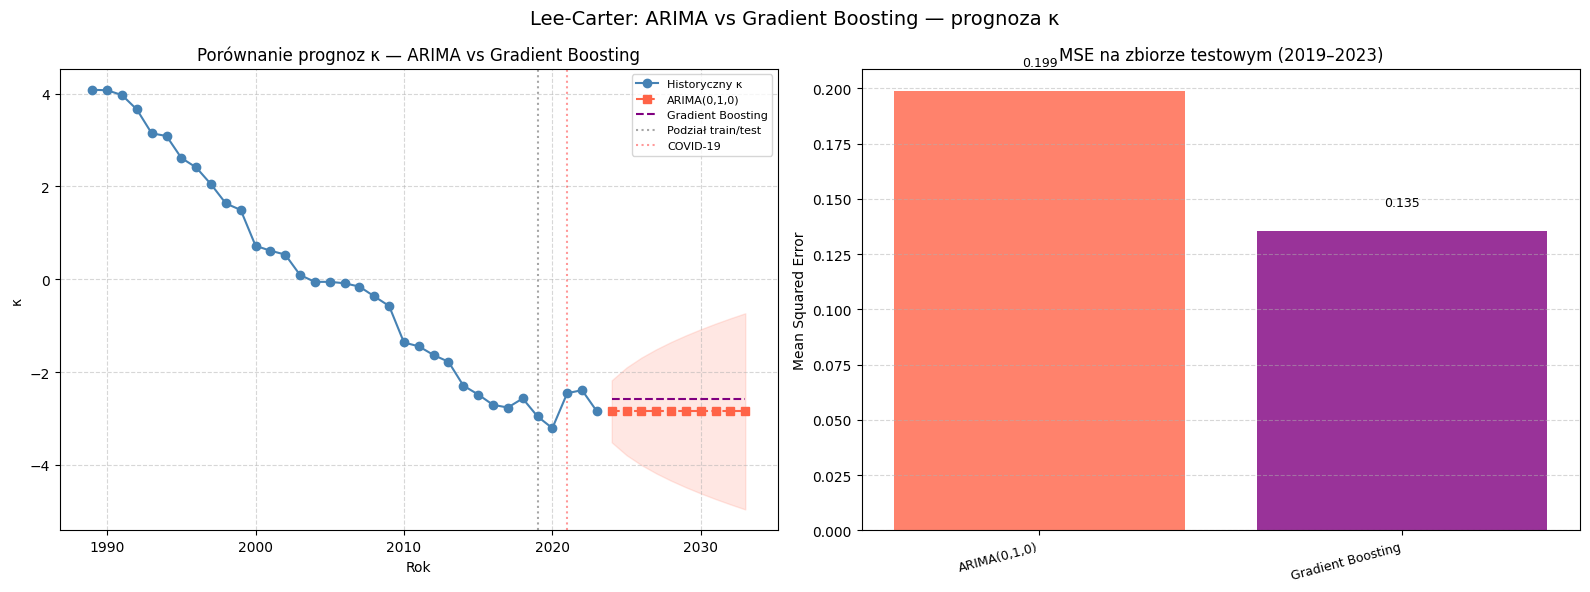

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(years, kappa, 'o-', color='steelblue', label='Historyczny κ', zorder=5)
axes[0].plot(future_years, kappa_future, 's--', color='tomato', label='ARIMA(0,1,0)')
axes[0].fill_between(future_years, conf_int['lower'], conf_int['upper'],
                     color='tomato', alpha=0.15)
axes[0].plot(future_years, gb_forecast, '--', color='purple', label='Gradient Boosting')

axes[0].axvline(x=split_date, color='gray', linestyle=':', alpha=0.7, label='Podział train/test')
axes[0].axvline(x=2021, color='red', linestyle=':', alpha=0.4, label='COVID-19')
axes[0].set_title('Porównanie prognoz κ — ARIMA vs Gradient Boosting')
axes[0].set_xlabel('Rok')
axes[0].set_ylabel('κ')
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.5)

arima_mse = mean_squared_error(y_test, arima.predict(start=split, end=len(years)-1))
all_mse = {'ARIMA(0,1,0)': arima_mse, 'Gradient Boosting': gb_mse}

bars = axes[1].bar(range(len(all_mse)), list(all_mse.values()),
                   color=['tomato', 'purple'], alpha=0.8)
axes[1].set_xticks(range(len(all_mse)))
axes[1].set_xticklabels(list(all_mse.keys()), rotation=15, ha='right', fontsize=9)
axes[1].set_title(f'MSE na zbiorze testowym ({split_date}–2023)')
axes[1].set_ylabel('Mean Squared Error')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars, all_mse.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Lee-Carter: ARIMA vs Gradient Boosting — prognoza κ', fontsize=14)
plt.tight_layout()
plt.show()

## Wnioski końcowe — ARIMA vs Gradient Boosting

### Wyniki przy różnych punktach podziału

| Split | Zbiór testowy | ARIMA MSE | GB MSE | Lepszy model |
|-------|--------------|-----------|--------|--------------|
| 2015  | 2015–2023    | 0.125     | 0.240  | ARIMA        |
| 2019  | 2019–2023    | 0.199     | 0.135  | GB           |
| 2020  | 2020–2023    | 0.211     | 0.159  | GB           |

### Interpretacja

Gradient Boosting przewyższa ARIMA wyłącznie przy krótkim horyzoncie
prognozy (4–5 lat), gdzie ekstrapolacja poza zakres treningowy jest
minimalna. Wraz z wydłużeniem horyzontu przewaga GB zanika i odwraca się —
przy zbiorze testowym obejmującym 9 lat MSE GB jest niemal dwukrotnie
wyższy niż ARIMA. Jest to bezpośrednia konsekwencja architektury drzew
decyzyjnych, które nie ekstrapolują trendu poza zakres danych treningowych.

### Wpływ anomalii COVID-19

Rok 2021 obecny w każdym zbiorze testowym zawyża MSE obu modeli,
ponieważ żadna metoda nie jest w stanie przewidzieć szoku pandemicznego
na podstawie danych historycznych. Porównanie MSE między modelami pozostaje
mimo to miarodajne, gdyż anomalia wpływa na oba jednakowo.

### Wniosek aktuarialny

W modelowaniu śmiertelności długoterminowej — typowym dla wyceny
ubezpieczeń na życie i rent — ARIMA osadzona w modelu Lee-Cartera
jest metodą bardziej niezawodną niż Gradient Boosting. GB może
stanowić uzupełnienie przy krótkoterminowych korektach taryfowych,
jednak wymaga wówczas jawnego modelowania szoków zewnętrznych
(np. zmienną dummy dla COVID) oraz regularnej rekalibracji
na najnowszych danych.